Caricare tutti i file JSON della cartella locale su HDFS

In [3]:
!hdfs dfs -put -f  /Users/margheritasantarossa/Desktop/CVE/datasets/nvd/*.json /hdfs_dir/

2025-10-08 16:41:10,429 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Verificare che i file siano effettivamente caricati su HDFS

In [4]:
!hdfs dfs -ls /hdfs_dir/

2025-10-08 16:41:39,917 WARN util.NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Found 11 items
-rw-r--r--   1 margheritasantarossa supergroup   52514299 2025-10-08 16:41 /hdfs_dir/nvdcve-2.0-2015.json
-rw-r--r--   1 margheritasantarossa supergroup   66078415 2025-10-08 16:41 /hdfs_dir/nvdcve-2.0-2016.json
-rw-r--r--   1 margheritasantarossa supergroup   93883549 2025-10-08 16:41 /hdfs_dir/nvdcve-2.0-2017.json
-rw-r--r--   1 margheritasantarossa supergroup   98708455 2025-10-08 16:41 /hdfs_dir/nvdcve-2.0-2018.json
-rw-r--r--   1 margheritasantarossa supergroup  111356146 2025-10-08 16:41 /hdfs_dir/nvdcve-2.0-2019.json
-rw-r--r--   1 margheritasantarossa supergroup  146390647 2025-10-08 16:41 /hdfs_dir/nvdcve-2.0-2020.json
-rw-r--r--   1 margheritasantarossa supergroup  174250873 2025-10-08 16:41 /hdfs_dir/nvdcve-2.0-2021.json
-rw-r--r--   1 margheritasantarossa supergroup  173719863 2025-10-08 16:41 /hdfs_dir/nvdc

In [5]:
# Se sei in notebook con cella magica
!pip install matplotlib pandas

In [37]:
pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 15.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 15.7 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [6]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode

# Crea/ricrea la sessione Spark con più memoria driver se serve
spark = SparkSession.builder \
        .appName("CVE_Analysis_Safe") \
        .config("spark.driver.memory", "4g") \
        .getOrCreate()

# Percorso del file JSON su HDFS
hdfs_file = "hdfs://localhost:9000/hdfs_dir/*.json"

# Leggi il file in modalità multiLine
df_raw = spark.read.option("multiLine", "true").json(hdfs_file)

df_raw.printSchema()
print(df_raw.count())
df_raw.select("version").distinct().show()

# Mostra solo il primo record
#df_selected.limit(1).show(truncate=False)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/10 10:29:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/10/10 10:29:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


root
 |-- format: string (nullable = true)
 |-- resultsPerPage: long (nullable = true)
 |-- startIndex: long (nullable = true)
 |-- timestamp: string (nullable = true)
 |-- totalResults: long (nullable = true)
 |-- version: string (nullable = true)
 |-- vulnerabilities: array (nullable = true)
 |    |-- element: struct (containsNull = true)
 |    |    |-- cve: struct (nullable = true)
 |    |    |    |-- cisaActionDue: string (nullable = true)
 |    |    |    |-- cisaExploitAdd: string (nullable = true)
 |    |    |    |-- cisaRequiredAction: string (nullable = true)
 |    |    |    |-- cisaVulnerabilityName: string (nullable = true)
 |    |    |    |-- configurations: array (nullable = true)
 |    |    |    |    |-- element: struct (containsNull = true)
 |    |    |    |    |    |-- nodes: array (nullable = true)
 |    |    |    |    |    |    |-- element: struct (containsNull = true)
 |    |    |    |    |    |    |    |-- cpeMatch: array (nullable = true)
 |    |    |    |    |    |

11


+-------+
|version|
+-------+
|    2.0|
+-------+



In [7]:
from pyspark.sql import functions as F

# Esplodi l’array delle vulnerabilità
df_exploded = df_raw.select(F.explode("vulnerabilities").alias("vuln"))

# Estrai i campi principali
df_cve = df_exploded.select(
    F.col("vuln.cve.id").alias("cve_id"),
    F.expr("filter(vuln.cve.descriptions, x -> x.lang = 'en')[0].value").alias("description"),
    F.col("vuln.cve.published").alias("published"),
    F.col("vuln.cve.metrics.cvssMetricV31")[0].alias("cvss")  # versione più recente e standard
)

# Estrai punteggio e severità CVSS
df_cve = df_cve.select(
    "cve_id",
    "description",
    "published",
    F.col("cvss.cvssData.baseScore").alias("baseScore"),
    F.col("cvss.cvssData.baseSeverity").alias("severity")
)

# Aggiungi la colonna “anno” estratta dalla data di pubblicazione
df_cve = df_cve.withColumn("year", F.substring(F.col("published"), 1, 4))

# Rimuovi CVE senza severità
df_cve_filtered = df_cve.filter(F.col("severity").isNotNull())

# Controlla un campione
df_cve_filtered.show(5, truncate=False)
print("Totale CVE con severità:", df_cve_filtered.count())

+--------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------------------+---------+--------+----+
|cve_id        |description                                                                                                                                                                                                                                                                                                                                                                                                                                      

[Stage 8:====================================================>     (9 + 1) / 10]

Totale CVE con severità: 169724


In [8]:
df_grouped = df_cve_filtered.groupBy("year", "severity").count().orderBy("year")
df_grouped.show()

[Stage 11:=============================================>           (8 + 2) / 10]

+----+--------+-----+
|year|severity|count|
+----+--------+-----+
|2015|  MEDIUM|    9|
|2015|    HIGH|   41|
|2015|CRITICAL|   24|
|2016|     LOW|    7|
|2016|  MEDIUM|  201|
|2016|CRITICAL|   92|
|2016|    HIGH|  466|
|2017|CRITICAL|  271|
|2017|     LOW|   22|
|2017|  MEDIUM|  564|
|2017|    HIGH|  785|
|2018|  MEDIUM|  611|
|2018|    HIGH|  844|
|2018|CRITICAL|  319|
|2018|     LOW|   21|
|2019|     LOW|  191|
|2019|  MEDIUM| 3617|
|2019|    HIGH| 3620|
|2019|CRITICAL| 1174|
|2020|CRITICAL| 2450|
+----+--------+-----+
only showing top 20 rows



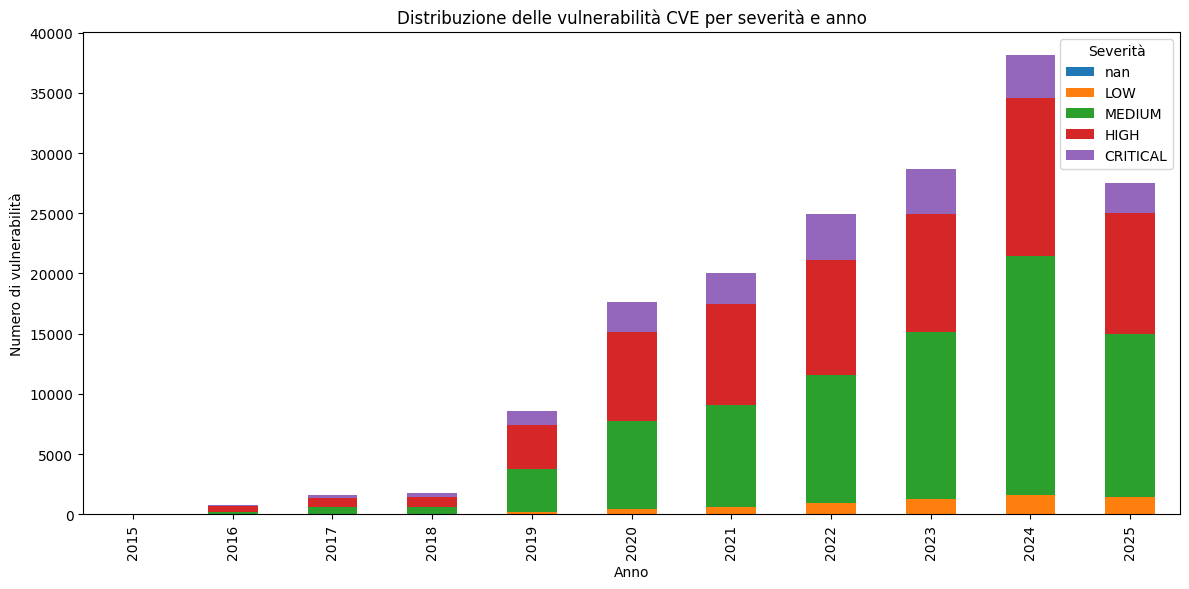

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Raggruppa per anno e severità
df_grouped = df_cve_filtered.groupBy("year", "severity").count().orderBy("year")

# Converti in pandas per il plotting
pdf = df_grouped.toPandas()

# Ordina le categorie di severità
severity_order = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
pdf["severity"] = pd.Categorical(pdf["severity"], categories=severity_order, ordered=True)

# Pivot per grafico
pdf_pivot = pdf.pivot(index="year", columns="severity", values="count").fillna(0)

# Plot stacked bar chart
pdf_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Distribuzione delle vulnerabilità CVE per severità e anno")
plt.xlabel("Anno")
plt.ylabel("Numero di vulnerabilità")
plt.legend(title="Severità")
plt.tight_layout()
plt.show()

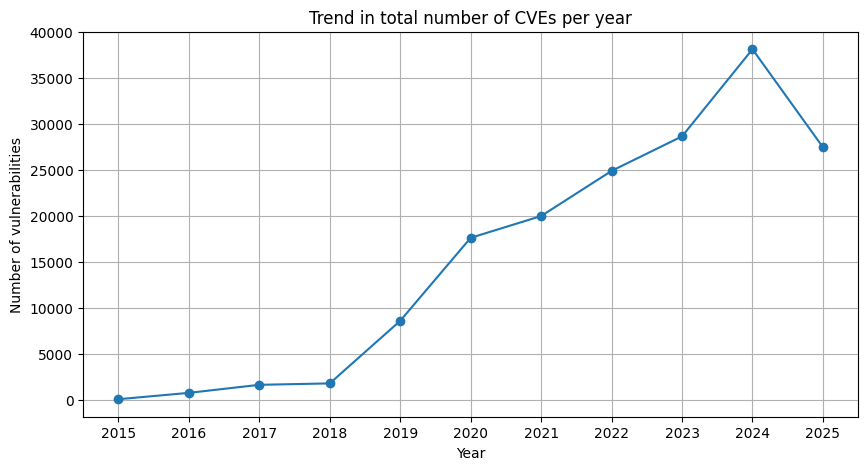

In [10]:
#Trend in total number of CVEs per year
#NOTE: 2025 is lower because still on-going

df_yearly = df_cve_filtered.groupBy("year").count().orderBy("year")
pdf_yearly = df_yearly.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(pdf_yearly["year"], pdf_yearly["count"], marker='o')
plt.title("Trend in total number of CVEs per year")
plt.xlabel("Year")
plt.ylabel("Number of vulnerabilities")
plt.grid(True)
plt.show()

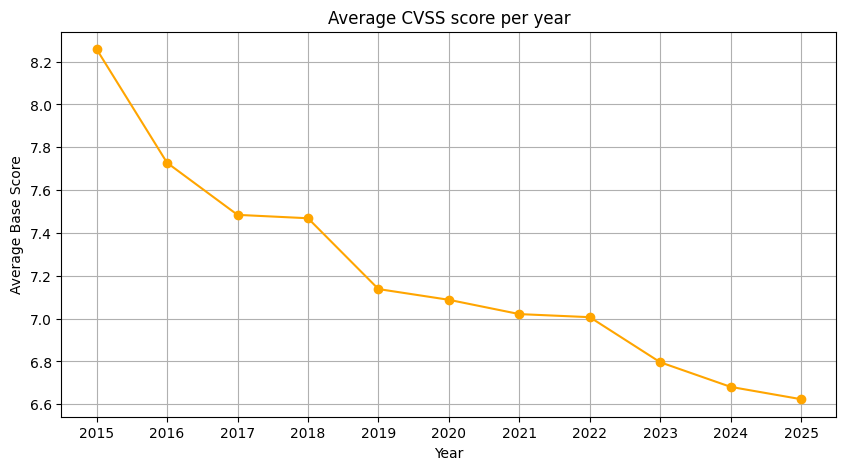

In [11]:
#Average CVSS score per year
df_score_trend = df_cve_filtered.groupBy("year").agg(
    F.avg("baseScore").alias("avg_score")
).orderBy("year")

pdf_score = df_score_trend.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(pdf_score["year"], pdf_score["avg_score"], marker='o', color='orange')
plt.title("Average CVSS score per year")
plt.xlabel("Year")
plt.ylabel("Average Base Score")
plt.grid(True)
plt.show()

#NOTE --> DA CAPIRE
#Se la media diminuisce, significa che:
#le vulnerabilità scoperte sono mediamente meno critiche,
#o che i sistemi sono più resilienti e i problemi più lievi.


In recent years, there has been a steady increase in the total number of reported vulnerabilities, accompanied by a decrease in the average CVSS score. This suggests an improved ability to detect and document less severe vulnerabilities, rather than a deterioration in the overall security of systems.

<Figure size 800x600 with 0 Axes>

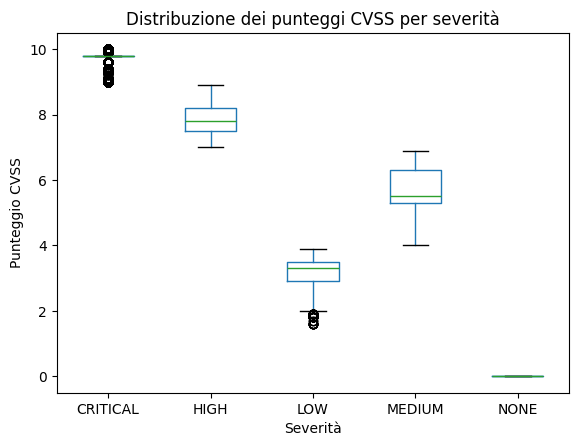

In [11]:
#Severity score distribution (boxplot)
pdf_scores = df_cve_filtered.select("severity", "baseScore").toPandas()

plt.figure(figsize=(8, 6))
pdf_scores.boxplot(column="baseScore", by="severity", grid=False)
plt.title("Distribuzione dei punteggi CVSS per severità")
plt.suptitle("")  # rimuove titolo doppio
plt.xlabel("Severità")
plt.ylabel("Punteggio CVSS")
plt.show()

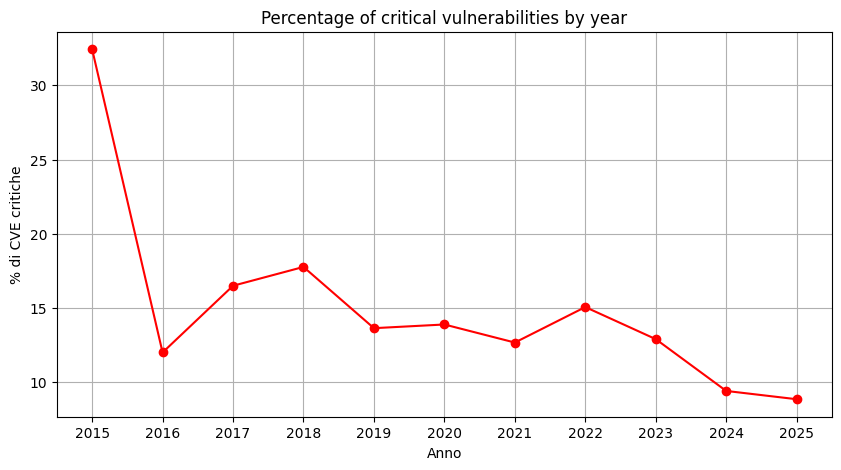

In [12]:
#Percentage of critical vulnerabilities by year

df_percent_critical = df_cve_filtered.groupBy("year").agg(
    (100 * F.sum(F.when(F.col("severity") == "CRITICAL", 1).otherwise(0)) / F.count("*")).alias("perc_critical")
).orderBy("year")

pdf_percent = df_percent_critical.toPandas()

plt.figure(figsize=(10, 5))
plt.plot(pdf_percent["year"], pdf_percent["perc_critical"], marker='o', color='red')
plt.title("Percentage of critical vulnerabilities by year")
plt.xlabel("Anno")
plt.ylabel("% di CVE critiche")
plt.grid(True)
plt.show()

In [13]:
#Textual analysis of descriptions
from pyspark.sql.functions import lower, regexp_replace, split, explode

df_words = df_cve_filtered.select(
    explode(split(
        regexp_replace(lower(F.col("description")), "[^a-zA-Z0-9 ]", ""),
        " "
    )).alias("word")
)

df_top_words = df_words.groupBy("word").count().orderBy(F.desc("count"))
df_top_words.filter(df_top_words.word.isin("sql", "xss", "overflow", "injection")).show()

[Stage 63:===================================================>     (9 + 1) / 10]

+---------+-----+
|     word|count|
+---------+-----+
|injection|17737|
|      xss|15981|
|      sql|15336|
| overflow|11927|
+---------+-----+



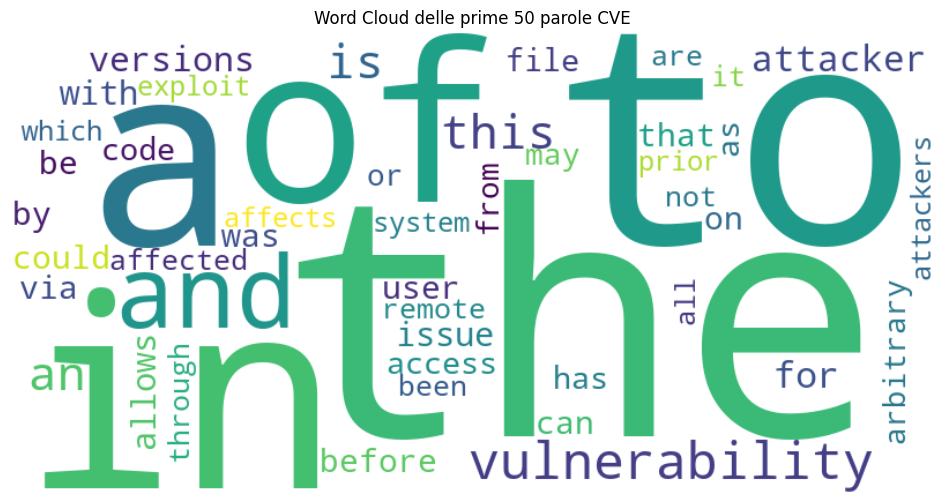

In [52]:
from pyspark.sql.functions import lower, regexp_replace, split, explode

# Clean and split descriptions into words
df_words = df_cve_filtered.select(
    explode(
        split(
            regexp_replace(lower(F.col("description")), "[^a-zA-Z0-9 ]", ""), 
            " "
        )
    ).alias("word")
)

df_word_counts = df_words.groupBy("word").count().orderBy(F.desc("count"))
#df_word_counts.show(50)  # Top 50 words

from wordcloud import WordCloud,STOPWORDS
import matplotlib.pyplot as plt

# Converti in Pandas e prendi solo le prime 50 parole
pdf_words_top50 = df_word_counts.limit(50).toPandas()

# Crea un dizionario {parola: frequenza} per WordCloud
word_freq = dict(zip(pdf_words_top50['word'], pdf_words_top50['count']))

# Genera la nuvola di parole
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis')
wc.generate_from_frequencies(word_freq)

# Mostra la nuvola
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud delle prime 50 parole CVE")
plt.show()

In [15]:
vuln_keywords = ["sql", "xss", "overflow", "injection", "csrf", "dos", "rce", "authentication", "privilege", "bypass"]
df_top_vuln_words = df_word_counts.filter(df_word_counts.word.isin(vuln_keywords))
df_top_vuln_words.show()

[Stage 50:===================================================>     (9 + 1) / 10]

+--------------+-----+
|          word|count|
+--------------+-----+
|     injection|17737|
|           xss|15981|
|           sql|15336|
|     privilege|11954|
|      overflow|11927|
|authentication| 7767|
|        bypass| 6865|
|           dos| 5765|
|          csrf| 5583|
|           rce|  962|
+--------------+-----+



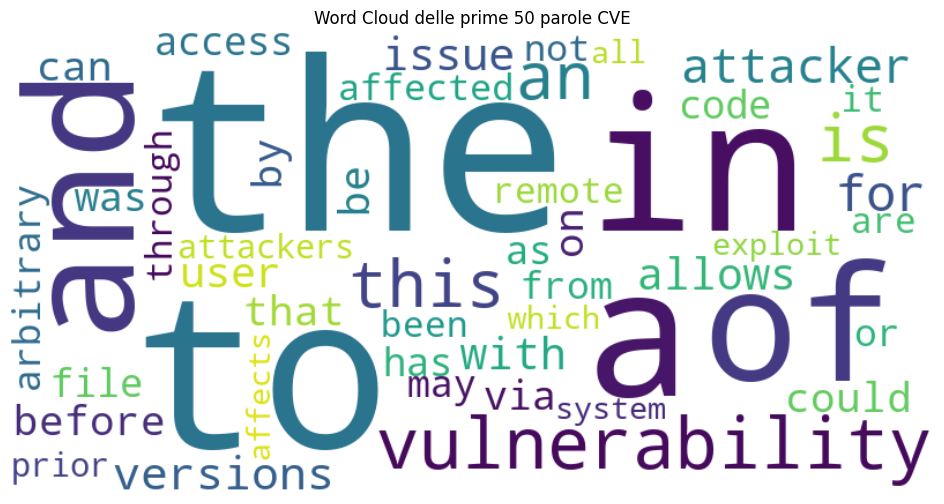

In [51]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Prendi le prime 50 parole
pdf_words_top50 = df_word_counts.limit(50).toPandas()

# Crea dizionario {parola: frequenza}
word_freq = dict(zip(pdf_words_top50['word'], pdf_words_top50['count']))

# Definisci stopwords personalizzate
stopwords = set(STOPWORDS)
stopwords.update(["will","announcing","via","none"])

# Genera la WordCloud
word_cloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap="viridis",
    stopwords=stopwords
).generate_from_frequencies(word_freq)

# Mostra la nuvola
plt.figure(figsize=(12,6))
plt.imshow(word_cloud, interpolation='bilinear')
plt.axis("off")
plt.title("Word Cloud delle prime 50 parole CVE")
plt.show()

In [44]:
!pip install wordcloud

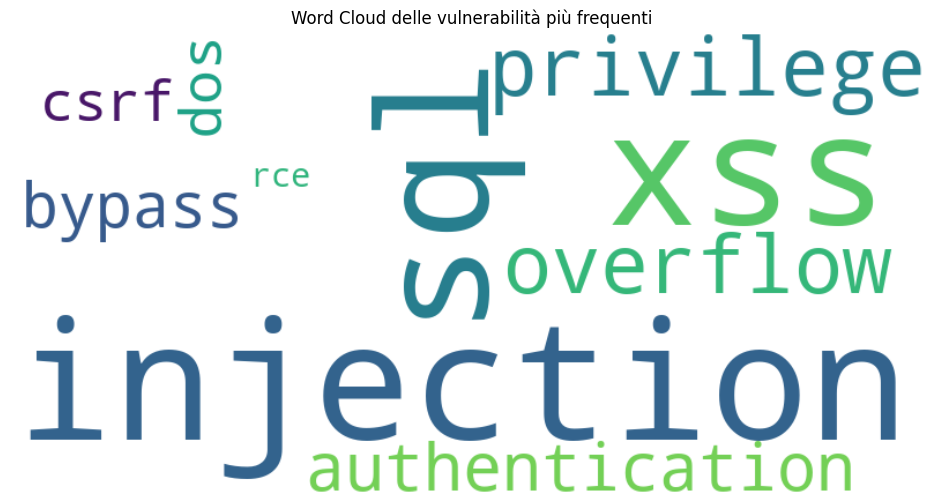

In [45]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Converti in Pandas
pdf_words = df_top_vuln_words.toPandas()

# Crea dizionario parola:frequenza
word_freq = dict(zip(pdf_words['word'], pdf_words['count']))

# Genera la word cloud
wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis')
wc.generate_from_frequencies(word_freq)

# Mostra
plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud delle vulnerabilità più frequenti")
plt.show()

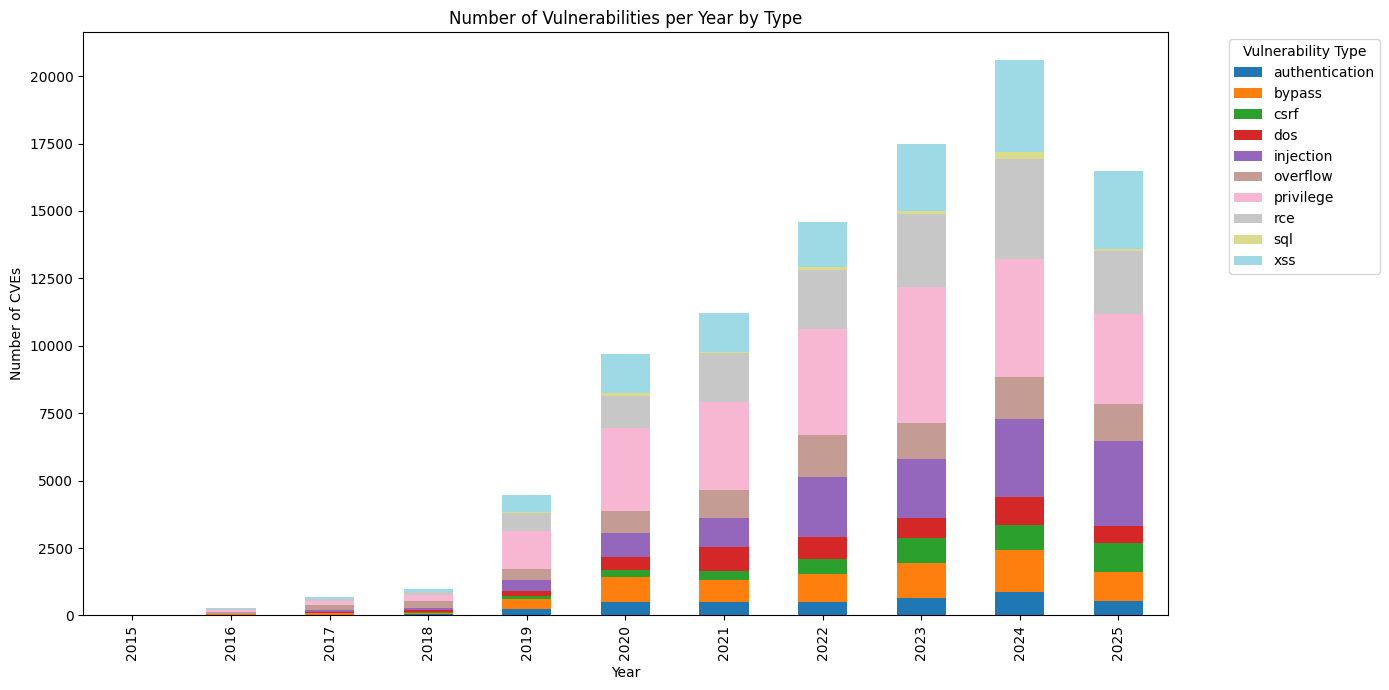

In [16]:
from pyspark.sql.functions import lower, col, when, lit

# Start with a column 'vuln_type' filled with None
df_cve_types = df_cve_filtered.withColumn("vuln_type", lit(None))

# List of vulnerability keywords
vuln_keywords = ["sql", "xss", "overflow", "injection", "csrf", "dos", "rce", "authentication", "privilege", "bypass"]

# Assign the type based on keywords in the description
for keyword in vuln_keywords:
    df_cve_types = df_cve_types.withColumn(
        "vuln_type",
        when(lower(col("description")).contains(keyword), keyword).otherwise(col("vuln_type"))
    )

# Keep only rows where vuln_type was assigned
df_cve_types = df_cve_types.filter(col("vuln_type").isNotNull())

df_grouped = df_cve_types.groupBy("year", "vuln_type").count().orderBy("year")
pdf_grouped = df_grouped.toPandas()

pdf_pivot = pdf_grouped.pivot(index="year", columns="vuln_type", values="count").fillna(0)

pdf_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(14,7),
    colormap="tab20"
)

plt.title("Number of Vulnerabilities per Year by Type")
plt.xlabel("Year")
plt.ylabel("Number of CVEs")
plt.legend(title="Vulnerability Type", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

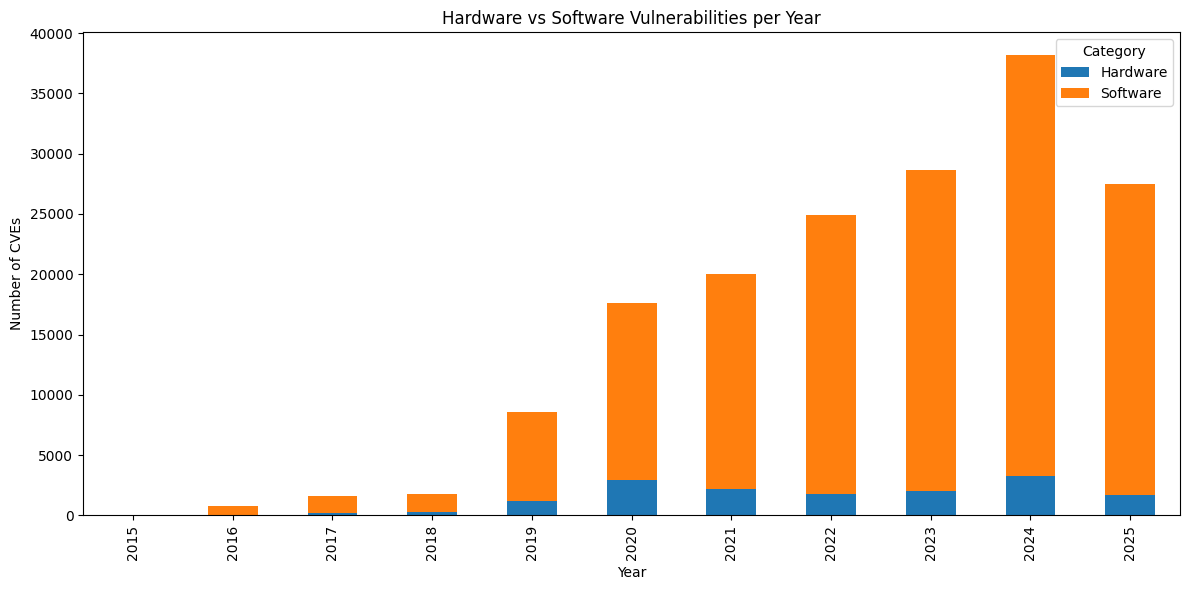

In [17]:
#Hardware vulnerabilities might contain words like "hardware", "chip", "firmware", "processor", "device", "embedded".
#Software vulnerabilities are everything else (most CVEs), often mentioning "code", "application", "system", "library", "plugin".

from pyspark.sql.functions import when, lower, col, lit

# Define hardware keywords
hardware_keywords = ["hardware", "chip", "firmware", "processor", "device", "embedded"]

# Start with 'vuln_category' as 'Software' by default
df_cve_category = df_cve_filtered.withColumn("vuln_category", lit("Software"))

# Check if description contains any hardware keyword
for hw in hardware_keywords:
    df_cve_category = df_cve_category.withColumn(
        "vuln_category",
        when(lower(col("description")).contains(hw), "Hardware").otherwise(col("vuln_category"))
    )


df_category_grouped = df_cve_category.groupBy("year", "vuln_category").count().orderBy("year")
pdf_category_grouped = df_category_grouped.toPandas()

pdf_category_pivot = pdf_category_grouped.pivot(index="year", columns="vuln_category", values="count").fillna(0)

pdf_category_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=["#1f77b4", "#ff7f0e"]
)

plt.title("Hardware vs Software Vulnerabilities per Year")
plt.xlabel("Year")
plt.ylabel("Number of CVEs")
plt.legend(title="Category")
plt.tight_layout()
plt.show()

In [42]:
#IT WORKS
from pyspark.sql import functions as F
from pyspark.sql.window import Window

df_cve_full = df_exploded.select(
    F.col("vuln.cve.id").alias("cve_id"),
    F.col("vuln.cve.published").alias("published"),
    F.col("vuln.cve.configurations").alias("configurations"),
    F.col("vuln.cve.metrics.cvssMetricV31").alias("cvss_v31"),
    F.col("vuln.cve.metrics.cvssMetricV30").alias("cvss_v30"),
    F.col("vuln.cve.metrics.cvssMetricV2").alias("cvss_v2")
)

df_vendor = df_cve_full.select(
    "cve_id",
    "published",
    "cvss_v31",
    "cvss_v30",
    "cvss_v2",
    F.explode_outer("configurations").alias("conf")
).select(
    "cve_id",
    "published",
    "cvss_v31",
    "cvss_v30",
    "cvss_v2",
    F.explode_outer("conf.nodes").alias("node")
).select(
    "cve_id",
    "published",
    "cvss_v31",
    "cvss_v30",
    "cvss_v2",
    F.explode_outer("node.cpeMatch").alias("cpe")
).withColumn(
    "vendor",
    F.regexp_extract(F.col("cpe.criteria"), r"cpe:2\.3:a:([^:]+):", 1)
).filter(F.col("vendor") != "")

df_vendor = df_vendor.withColumn("year", F.year(F.to_date("published")))

df_vendor = df_vendor.withColumn(
    "cvss",
    F.when(F.col("cvss_v31")[0].cvssData.baseScore.isNotNull(),
           F.col("cvss_v31")[0].cvssData.baseScore)
     .when(F.col("cvss_v30")[0].cvssData.baseScore.isNotNull(),
           F.col("cvss_v30")[0].cvssData.baseScore)
     .otherwise(F.col("cvss_v2")[0].cvssData.baseScore)
)

# Step 4: aggregate by vendor and year (count + average severity)
vendor_stats = df_vendor.groupBy("vendor", "year").agg(
    F.count("*").alias("vuln_count"),
    F.avg("cvss").alias("avg_cvss")
)

# Step 5: keep only vendors with enough total CVEs (for more stable trends)
vendor_totals = vendor_stats.groupBy("vendor").agg(F.sum("vuln_count").alias("total_cve"))
top_vendors = vendor_totals.filter(F.col("total_cve") >= 30).select("vendor")
vendor_stats = vendor_stats.join(top_vendors, "vendor", "inner")

# Step 6: define window to compute year-over-year changes
window_vendor = Window.partitionBy("vendor").orderBy("year")

vendor_evolution = vendor_stats.withColumn(
    "prev_year_count", F.lag("vuln_count").over(window_vendor)
).withColumn(
    "prev_avg_cvss", F.lag("avg_cvss").over(window_vendor)
).withColumn(
    "growth_rate",
    F.when(F.col("prev_year_count").isNotNull(),
           (F.col("vuln_count") - F.col("prev_year_count")) / F.col("prev_year_count"))
).withColumn(
    "cvss_change",
    F.when(F.col("prev_avg_cvss").isNotNull(),
           F.col("avg_cvss") - F.col("prev_avg_cvss"))
)

# Step 7: classify vendors based on trends
vendor_evolution = vendor_evolution.withColumn(
    "trend",
    F.when((F.col("growth_rate") > 0.2) & (F.col("cvss_change") > 0), "Emerging & Riskier")
     .when((F.col("growth_rate") > 0.2) & (F.col("cvss_change") <= 0), "Emerging but Safer")
     .when((F.col("growth_rate") <= 0) & (F.col("cvss_change") > 0), "Declining but Riskier")
     .otherwise("Stable or Improving")
)

# Step 8: exclude incomplete year 2025
vendor_evolution = vendor_evolution.filter(F.col("year") <= 2024)

# Step 9: sort and display results
vendor_summary = vendor_evolution.orderBy("vendor", "year")
#vendor_summary.show(50, truncate=False)


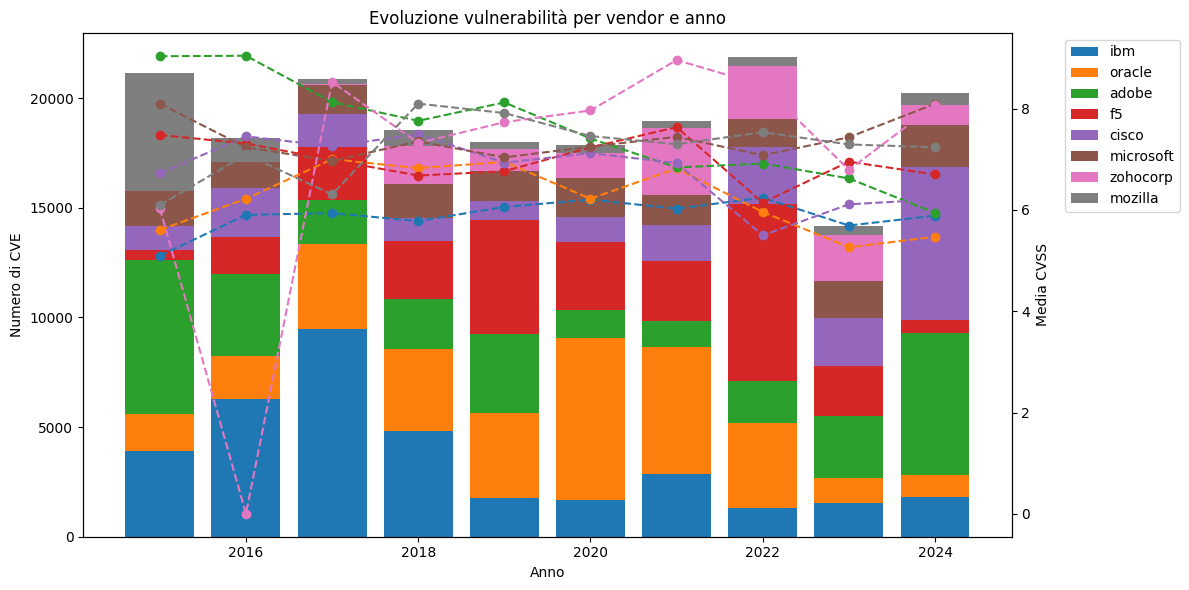

In [37]:
import matplotlib.pyplot as plt
import pandas as pd

# Converti in pandas e normalizza vendor
pdf = vendor_summary.toPandas()
pdf["vendor"] = pdf["vendor"].astype(str)

# Ordina vendor per numero di vulnerabilità
vendor_order = pdf.groupby("vendor")["vuln_count"].sum().sort_values(ascending=False).index
vendors = vendor_order[:8]
pdf = pdf[pdf["vendor"].isin(vendors)]

fig, ax1 = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10.colors
years = sorted(pdf["year"].unique())
bottom = pd.Series([0]*len(years), index=years, dtype=float)

for i, vendor in enumerate(vendors):
    data = (
        pdf[pdf["vendor"] == vendor]
        .set_index("year")[["vuln_count", "avg_cvss"]]  # solo numeriche
        .reindex(years, fill_value=0)
    )
    ax1.bar(years, data["vuln_count"], bottom=bottom, color=colors[i % len(colors)], label=vendor)
    bottom += data["vuln_count"]

ax1.set_xlabel("Anno")
ax1.set_ylabel("Numero di CVE")
ax1.set_title("Evoluzione vulnerabilità per vendor e anno")
ax1.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

# Aggiungi linea media CVSS
ax2 = ax1.twinx()
for i, vendor in enumerate(vendors):
    data = (
        pdf[pdf["vendor"] == vendor]
        .set_index("year")[["vuln_count", "avg_cvss"]]
        .reindex(years, fill_value=0)
    )
    ax2.plot(years, data["avg_cvss"], color=colors[i % len(colors)], linestyle="--", marker="o")

ax2.set_ylabel("Media CVSS")

plt.tight_layout()
plt.show()

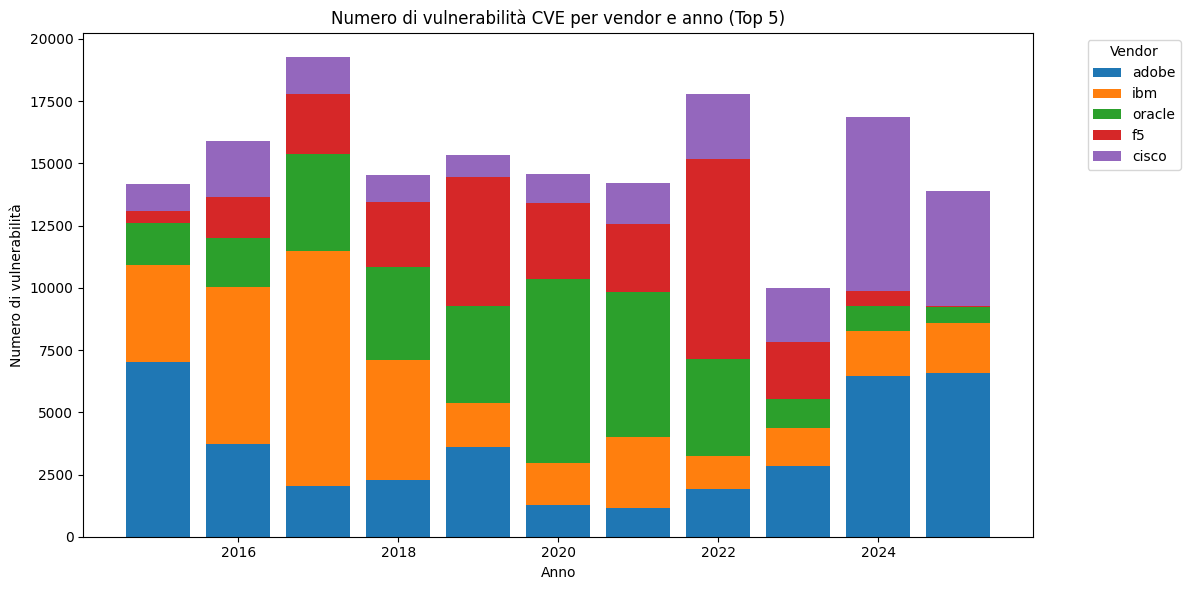

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# Converti Spark DataFrame in Pandas
pdf = vendor_stats.toPandas()

# Assicurati che l'anno sia int
pdf["year"] = pdf["year"].astype(int)

# Calcola i top vendor in base al totale di vulnerabilità
top_vendors = pdf.groupby("vendor")["vuln_count"].sum().sort_values(ascending=False).head(5).index.tolist()

# Filtra solo i top vendor
pdf_top = pdf[pdf["vendor"].isin(top_vendors)]

# Colori per i vendor
colors = plt.cm.tab10.colors  # meno colori visto che sono pochi vendor

# --------------------------
# Grafico a barre colorate per top vendor
# --------------------------
years = sorted(pdf_top["year"].unique())
fig, ax = plt.subplots(figsize=(12,6))

bottom = pd.Series([0]*len(years), index=years)

for i, vendor in enumerate(top_vendors):
    data = pdf_top[pdf_top["vendor"]==vendor].set_index("year").reindex(years, fill_value=0)
    ax.bar(years, data["vuln_count"], bottom=bottom, color=colors[i % len(colors)], label=vendor)
    bottom += data["vuln_count"]

ax.set_title("Numero di vulnerabilità CVE per vendor e anno (Top 5)")
ax.set_xlabel("Anno")
ax.set_ylabel("Numero di vulnerabilità")
ax.legend(title="Vendor", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

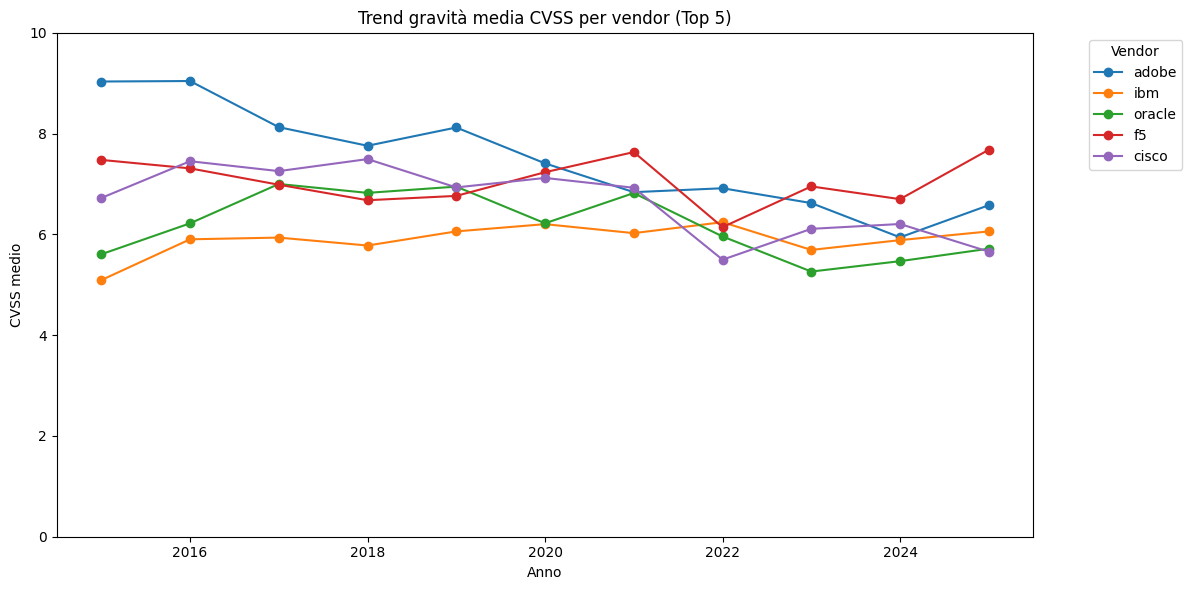

In [41]:
import matplotlib.pyplot as plt
import pandas as pd

# Converti Spark DataFrame in Pandas
pdf = vendor_stats.toPandas()

# Assicurati che l'anno sia int
pdf["year"] = pdf["year"].astype(int)

# Calcola i top vendor in base al totale di vulnerabilità
top_vendors = pdf.groupby("vendor")["vuln_count"].sum().sort_values(ascending=False).head(5).index.tolist()

# Filtra solo i top vendor
pdf_top = pdf[pdf["vendor"].isin(top_vendors)]

# Colori per i vendor
colors = plt.cm.tab10.colors  # meno colori visto che sono pochi vendor
# --------------------------
# Grafico trend CVSS per Top 5 vendor
# --------------------------
fig, ax2 = plt.subplots(figsize=(12,6))

for i, vendor in enumerate(top_vendors):
    data = pdf_top[pdf_top["vendor"]==vendor].set_index("year").reindex(years, fill_value=0)
    ax2.plot(years, data["avg_cvss"], marker='o', color=colors[i % len(colors)], label=vendor)

ax2.set_title("Trend gravità media CVSS per vendor (Top 5)")
ax2.set_xlabel("Anno")
ax2.set_ylabel("CVSS medio")
ax2.set_ylim(0, 10)  # scala CVSS standard
ax2.legend(title="Vendor", bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()